In [1]:
!pip install yfinance
!pip install ta

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=53682a6f88024d14e21a209757a080b20ca06da73f3ddcff84e1651d81b52cfe
  Stored in directory: /root/.cache/pip/wheels/5f/67/4f/8a9f252836e053e532c6587a3230bc72a4deb16b03a829610b
Successfully built ta


In [2]:
import pandas as pd
import yfinance as yf
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [3]:
tickers = ['^GSPC', '^DJI' , '^IXIC', '^VIX', 'JPY=X', 'CL=F', "^IRX", 'X03G.DE',
           '^TYX', '^TNX', 'TN=F', 'DX-Y.NYB', 'GBPUSD=X', 'DBC', 'EWZ', 'MUB',
           'AGG', 'SPY', 'GC=F', '^FVX', "XLE", "XLK", "CNYUSD=X", "JPYUSD=X",
            "^HSI", "EURUSD=X", "GBPUSD=X", "LQD", '^RUI']


In [4]:
data = yf.download(tickers, start="1999-01-01", end="2024-12-31", group_by="ticker")

data = pd.DataFrame({ticker: data[ticker]['Close'] for ticker in tickers})

data.reset_index(inplace=True)


[*********************100%***********************]  28 of 28 completed


In [5]:
data.columns

Index(['Date', '^GSPC', '^DJI', '^IXIC', '^VIX', 'JPY=X', 'CL=F', '^IRX',
       'X03G.DE', '^TYX', '^TNX', 'TN=F', 'DX-Y.NYB', 'GBPUSD=X', 'DBC', 'EWZ',
       'MUB', 'AGG', 'SPY', 'GC=F', '^FVX', 'XLE', 'XLK', 'CNYUSD=X',
       'JPYUSD=X', '^HSI', 'EURUSD=X', 'LQD', '^RUI'],
      dtype='object')

In [6]:
data.rename(columns={'^GSPC': 'SP500', '^DJI': 'DowJones', '^IXIC': 'NASDAQ', '^VIX': 'VIX', 'JPY=X': 'JPY', '^TYX': 'TY30', '^TNX': 'TNX', 'GC=F': 'GOLD', 'CL=F': 'OIL', '^IRX': 'IRX', 'CNYUSD=X': 'CNYUSD', 'JPYUSD=X': 'JPYUSD', '^RUI': 'RUI' }, inplace=True)


In [7]:
# Backward fill followed by forward fill
data.fillna(method='bfill', inplace=True)
data.fillna(method='ffill', inplace=True)
data.fillna(0, inplace=True)

<ipython-input-7-d778e5444d74>:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='bfill', inplace=True)
<ipython-input-7-d778e5444d74>:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)


In [8]:
data.head()

,Date,SP500,DowJones,NASDAQ,VIX,JPY,OIL,IRX,X03G.DE,TY30,...,GOLD,^FVX,XLE,XLK,CNYUSD,JPYUSD,^HSI,EURUSD=X,LQD,RUI
0,1999-01-01,1228.099976,9184.269531,2208.050049,26.170000,113.459999,32.049999,4.37,169.394363,5.147,...,273.899994,4.560,11.966019,24.739544,0.12082,0.008814,9809.169922,1.196501,39.254559,641.780029
1,1999-01-04,1228.099976,9184.269531,2208.050049,26.170000,111.910004,32.049999,4.37,169.394363,5.147,...,273.899994,4.560,11.966019,24.739544,0.12082,0.008936,9809.169922,1.196501,39.254559,641.780029
2,1999-01-05,1244.780029,9311.190430,2251.270020,24.459999,111.900002,32.049999,4.37,169.394363,5.202,...,273.899994,4.612,11.901897,25.372086,0.12082,0.008937,9891.059570,1.196501,39.254559,649.750000
3,1999-01-06,1272.339966,9544.969727,2320.860107,23.340000,112.750000,32.049999,4.37,169.394363,5.167,...,273.899994,4.612,12.294617,26.121778,0.12082,0.008869,10233.799805,1.196501,39.254559,663.669983
4,1999-01-07,1269.729980,9537.759766,2326.090088,24.370001,111.309998,32.049999,4.31,169.394363,5.220,...,273.899994,4.612,12.238514,26.039766,0.12082,0.008984,10693.570312,1.196501,39.254559,662.719971


In [9]:
log_return_columns = ['DowJones', 'SP500', 'NASDAQ', 'VIX', 'GOLD', 'OIL']
for col in log_return_columns:
    data[f'{col}_log_return'] = np.log(data[col] / data[col].shift(1))


/usr/local/lib/python3.10/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [10]:
##Calculate Small Minus Big
RUI_Return = np.log(data['RUI'] / data['RUI'].shift(1))
SP500_Return = np.log(data['SP500'] / data['SP500'].shift(1))

data['SMB'] = RUI_Return - SP500_Return
data['SMB_Binary'] = (data['SMB'] > 0).astype(int)

# Drop NaN values caused by the first shift
data.dropna(inplace=True)

In [11]:
data[['SMB', 'SMB_Binary']]

,SMB,SMB_Binary
1,0.000000,0
2,-0.001149,0
3,-0.000702,0
4,0.000621,1
5,0.000184,1
...,...,...
6777,-0.000156,0
6778,0.000134,1
6779,0.000000,0
6780,-0.000067,0


In [12]:
epsilon = 1e-6
data['USGG3M'] = data['IRX'].apply(lambda x: x if x > epsilon else epsilon)
data['Bond_10yr_to_3mo'] = data['TNX'] / data['USGG3M']
data['Bond_30yr_to_2yr'] = data['TY30'] / data['^FVX']
data['Gold_to_SP500'] = data['GOLD'] / data['SP500']
data['Oil_to_SP500'] = data['OIL'] / data['SP500']
data['Bond_10yr_diff'] = data['TNX'].diff(5)
data['Bond_30yr_diff'] = data['TY30'].diff(5)
data['SP500_MA_diff'] = data['SP500'].rolling(5).mean() - data['SP500'].rolling(20).mean()

In [13]:
from ta.momentum import RSIIndicator

# MACD Function
def calculate_macd(data, column):
    ema_12 = data[column].ewm(span=12, adjust=False).mean()
    ema_26 = data[column].ewm(span=26, adjust=False).mean()
    macd = ema_12 - ema_26
    macd_signal = macd.ewm(span=9, adjust=False).mean()
    return macd, macd_signal

# Rolling Volatility Function
def calculate_rolling_volatility(data, column, window=10):
    return data[column].pct_change().rolling(window=window).std()

# Rolling Moving Averages Function
def calculate_moving_averages(data, column, short_window=5, long_window=20):
    short_ma = data[column].rolling(window=short_window).mean()
    long_ma = data[column].rolling(window=long_window).mean()
    return short_ma, long_ma

# Define the current tickers in the dataset
features_with_macd_rsi = ['SP500', 'DowJones', 'GOLD', 'DX-Y.NYB', 'OIL']  # S&P 500, Dow Jones, Gold, USD Index, Crude Oil
features_with_rolling_only = ['VIX']  # Volatility Inde

# Adding MACD, RSI, Rolling Volatility, and Moving Averages for selected features
for feature in features_with_macd_rsi:
    # Ensure feature exists in the dataset
    if feature in data.columns:
        # MACD
        data[f'{feature}_MACD'], data[f'{feature}_MACD_signal'] = calculate_macd(data, feature)

        # RSI
        rsi = RSIIndicator(data[feature], window=14)
        data[f'{feature}_RSI'] = rsi.rsi()

        # Rolling Volatility
        data[f'{feature}_volatility'] = calculate_rolling_volatility(data, feature)

        # Rolling Moving Averages
        data[f'{feature}_MA_short'], data[f'{feature}_MA_long'] = calculate_moving_averages(data, feature)

# Adding Rolling Volatility and Moving Averages for features without MACD or RSI
for feature in features_with_rolling_only:
    # Ensure feature exists in the dataset
    if feature in data.columns:
        # Rolling Volatility
        data[f'{feature}_volatility'] = calculate_rolling_volatility(data, feature)

        # Rolling Moving Averages
        data[f'{feature}_MA_short'], data[f'{feature}_MA_long'] = calculate_moving_averages(data, feature)

# Calculate rolling volatilities (e.g., 5-day rolling standard deviation of log returns)
for col in log_return_columns:
    data[f'{col}_volatility'] = data[f'{col}_log_return'].rolling(window=5).std()

data['SP500_RSI_x_SP500_volatility'] = data['SP500_RSI'] * data['SP500_volatility']
data['Gold_to_SP500_x_SP500_RSI'] = data['Gold_to_SP500'] * data['SP500_RSI']
data['Daily_Return'] = data['SP500'].pct_change()
data['Crash'] = (data['Daily_Return'] < -0.02).astype(int)

In [14]:
# Calculate the 1st percentile of log-returns for each day
thresholds = data['SP500_log_return'].rolling(window=200).quantile(0.01)

# Define crisis event as log-returns below the threshold
data['crisis'] = (data['SP500_log_return'] < thresholds).astype(int)

# Shift the binary variable for a one-day prediction horizon
data['crisis'] = data['crisis'].shift(-1)

# Drop rows where 'crisis' is NaN
data.dropna(subset=['crisis'], inplace=True)

In [15]:
data.columns

Index(['Date', 'SP500', 'DowJones', 'NASDAQ', 'VIX', 'JPY', 'OIL', 'IRX',
       'X03G.DE', 'TY30', 'TNX', 'TN=F', 'DX-Y.NYB', 'GBPUSD=X', 'DBC', 'EWZ',
       'MUB', 'AGG', 'SPY', 'GOLD', '^FVX', 'XLE', 'XLK', 'CNYUSD', 'JPYUSD',
       '^HSI', 'EURUSD=X', 'LQD', 'RUI', 'DowJones_log_return',
       'SP500_log_return', 'NASDAQ_log_return', 'VIX_log_return',
       'GOLD_log_return', 'OIL_log_return', 'SMB', 'SMB_Binary', 'USGG3M',
       'Bond_10yr_to_3mo', 'Bond_30yr_to_2yr', 'Gold_to_SP500', 'Oil_to_SP500',
       'Bond_10yr_diff', 'Bond_30yr_diff', 'SP500_MA_diff', 'SP500_MACD',
       'SP500_MACD_signal', 'SP500_RSI', 'SP500_volatility', 'SP500_MA_short',
       'SP500_MA_long', 'DowJones_MACD', 'DowJones_MACD_signal',
       'DowJones_RSI', 'DowJones_volatility', 'DowJones_MA_short',
       'DowJones_MA_long', 'GOLD_MACD', 'GOLD_MACD_signal', 'GOLD_RSI',
       'GOLD_volatility', 'GOLD_MA_short', 'GOLD_MA_long', 'DX-Y.NYB_MACD',
       'DX-Y.NYB_MACD_signal', 'DX-Y.NYB_RSI', 'DX-

In [16]:
# Create lagged windows for the Crash column
data['Crash_1D'] = data['Crash'].shift(-1)
data['Crash_3D'] = data['Crash'].shift(-3)
data['Crash_5D'] = data['Crash'].shift(-5)
data['Crash_7D'] = data['Crash'].shift(-7)

# Create lagged windows for the Crisis column
data['Crisis_1D'] = data['crisis'].shift(-1)
data['Crisis_3D'] = data['crisis'].shift(-3)
data['Crisis_5D'] = data['crisis'].shift(-5)
data['Crisis_7D'] = data['crisis'].shift(-7)



# More lagged features
lagged_columns = ['LQD', 'TNX', 'CNYUSD', 'JPYUSD', 'VIX']
for col in lagged_columns:
    for lag in range(1, 6):  # Create 1-day to 5-day lags
        data[f'{col}_lag{lag}'] = data[col].shift(lag)

In [17]:
data.fillna(method='ffill', inplace=True)
data.fillna(0, inplace=True)
data.head()

<ipython-input-17-18b40b59a1d7>:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)


,Date,SP500,DowJones,NASDAQ,VIX,JPY,OIL,IRX,X03G.DE,TY30,...,JPYUSD_lag1,JPYUSD_lag2,JPYUSD_lag3,JPYUSD_lag4,JPYUSD_lag5,VIX_lag1,VIX_lag2,VIX_lag3,VIX_lag4,VIX_lag5
1,1999-01-04,1228.099976,9184.269531,2208.050049,26.170000,111.910004,32.049999,4.37,169.394363,5.147,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.00,0.0
2,1999-01-05,1244.780029,9311.190430,2251.270020,24.459999,111.900002,32.049999,4.37,169.394363,5.202,...,0.008936,0.000000,0.000000,0.000000,0.0,26.170000,0.000000,0.000000,0.00,0.0
3,1999-01-06,1272.339966,9544.969727,2320.860107,23.340000,112.750000,32.049999,4.37,169.394363,5.167,...,0.008937,0.008936,0.000000,0.000000,0.0,24.459999,26.170000,0.000000,0.00,0.0
4,1999-01-07,1269.729980,9537.759766,2326.090088,24.370001,111.309998,32.049999,4.31,169.394363,5.220,...,0.008869,0.008937,0.008936,0.000000,0.0,23.340000,24.459999,26.170000,0.00,0.0
5,1999-01-08,1275.089966,9643.320312,2344.409912,23.280001,110.800003,32.049999,4.36,169.394363,5.256,...,0.008984,0.008869,0.008937,0.008936,0.0,24.370001,23.340000,24.459999,26.17,0.0


In [18]:
pd.set_option('display.max_rows', None)  # Show all rows
pd.set_option('display.max_columns', None)

In [19]:
len(data.columns)

117

In [20]:
correlation_with_Y = data.corr()['Crash'].sort_values(ascending=False)
print(correlation_with_Y)

Crash                           1.000000
VIX_log_return                  0.413845
VIX                             0.357626
SP500_volatility                0.320931
DowJones_volatility             0.313784
VIX_MA_short                    0.279517
NASDAQ_volatility               0.260838
VIX_lag2                        0.260611
VIX_lag3                        0.255691
VIX_lag1                        0.255650
VIX_lag4                        0.247323
VIX_lag5                        0.243169
VIX_MA_long                     0.239303
SP500_RSI_x_SP500_volatility    0.214609
VIX_volatility                  0.199972
DX-Y.NYB_volatility             0.160768
OIL_volatility                  0.135247
GOLD_volatility                 0.123313
Crash_7D                        0.106947
Crash_5D                        0.103272
Crash_3D                        0.095922
Crisis_1D                       0.083068
Crash_1D                        0.077546
Gold_to_SP500                   0.058997
Bond_10yr_to_3mo

In [21]:
correlation_with_Y = data.corr()['Crisis_5D'].sort_values(ascending=False)
print(correlation_with_Y)

Crisis_5D                       1.000000
Crisis_3D                       0.107993
Crisis_7D                       0.107993
Crisis_1D                       0.071830
VIX_volatility                  0.058277
SP500_volatility                0.055173
DowJones_volatility             0.053170
Crash_5D                        0.049788
crisis                          0.047722
NASDAQ_volatility               0.043333
Crash_3D                        0.043132
Crash                           0.036477
OIL_MA_long                     0.034695
VIX                             0.032452
VIX_lag1                        0.031972
SP500_RSI_x_SP500_volatility    0.031070
OIL_MA_short                    0.030466
GOLD_volatility                 0.028839
OIL                             0.028501
VIX_MA_short                    0.025105
Crash_1D                        0.023165
Crash_7D                        0.023165
VIX_lag2                        0.022777
DBC                             0.022487
VIX_lag3        

In [22]:
data['Date'] = pd.to_datetime(data['Date'])

In [23]:
correlation_with_Y = data.corr()['crisis'].sort_values(ascending=False)
print(correlation_with_Y)

crisis                          1.000000
Crash_1D                        0.455795
DowJones_volatility             0.085913
SP500_volatility                0.085405
VIX_volatility                  0.084963
Crash_3D                        0.076412
Crash_7D                        0.069756
NASDAQ_volatility               0.067121
VIX                             0.063496
VIX_lag1                        0.060018
Crisis_7D                       0.059776
Crisis_1D                       0.059776
SP500_RSI_x_SP500_volatility    0.053004
VIX_lag2                        0.050906
VIX_MA_short                    0.050876
Crash                           0.049788
Crash_5D                        0.049788
OIL_volatility                  0.048191
Crisis_5D                       0.047722
Crisis_3D                       0.047722
VIX_lag3                        0.041446
VIX_lag4                        0.034437
VIX_lag5                        0.032539
OIL_MA_long                     0.032050
DX-Y.NYB_volatil

In [24]:
#Get most important features using Lasso Regression
from sklearn.linear_model import Lasso

X_train = data.drop(columns=['Date', 'crisis', 'Crash', 'Crisis_1D', 'Crisis_3D', 'Crisis_5D', 'Crisis_7D', 'Crash_1D', 'Crash_3D', 'Crash_5D', 'Crash_7D'])

y_train = data['crisis']

lasso = Lasso(alpha=0.0005, random_state=42).fit(X_train, y_train)

# Get selected features
selected_features = X_train.columns[lasso.coef_ != 0]
print("Selected Features:", selected_features)

Selected Features: Index(['SP500', 'DowJones', 'NASDAQ', 'VIX', 'JPY', 'OIL', 'IRX', 'X03G.DE',
       'TN=F', 'DX-Y.NYB', 'DBC', 'MUB', 'AGG', 'SPY', 'GOLD', 'XLE', 'XLK',
       '^HSI', 'LQD', 'RUI', 'Bond_10yr_to_3mo', 'Bond_30yr_to_2yr',
       'SP500_MA_diff', 'SP500_MACD_signal', 'SP500_RSI', 'SP500_MA_short',
       'SP500_MA_long', 'DowJones_MACD', 'DowJones_MACD_signal',
       'DowJones_RSI', 'DowJones_MA_short', 'DowJones_MA_long', 'GOLD_MACD',
       'GOLD_RSI', 'GOLD_MA_short', 'GOLD_MA_long', 'DX-Y.NYB_RSI',
       'DX-Y.NYB_MA_short', 'DX-Y.NYB_MA_long', 'OIL_MACD_signal', 'OIL_RSI',
       'OIL_MA_short', 'OIL_MA_long', 'VIX_MA_long',
       'Gold_to_SP500_x_SP500_RSI', 'LQD_lag1', 'LQD_lag2', 'LQD_lag3',
       'LQD_lag4', 'LQD_lag5', 'VIX_lag1', 'VIX_lag2', 'VIX_lag3', 'VIX_lag4',
       'VIX_lag5'],
      dtype='object')


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.951e+01, tolerance: 8.296e-03
  model = cd_fast.enet_coordinate_descent(


In [25]:
#Split up our data
train_data = data[data['Date'] <= '2022-12-31']
verify_data = data[data['Date'] > '2022-12-31']

# Reset indices for both datasets
train_data.reset_index(drop=True, inplace=True)
verify_data.reset_index(drop=True, inplace=True)

In [26]:
# features = ['AGG',
#  'Bond_10yr_diff',
#  'Bond_10yr_to_3mo',
#  'Bond_30yr_diff',
#  'Bond_30yr_to_2yr',
#  'Crash_3D',
#  'DBC',
#  'DX-Y.NYB',
#  'DX-Y.NYB_MA_long',
#  'DX-Y.NYB_MA_short',
#  'DX-Y.NYB_RSI',
#  'DowJones',
#  'DowJones_MACD',
#  'DowJones_MACD_signal',
#  'DowJones_MA_long',
#  'DowJones_MA_short',
#  'DowJones_RSI',
#  'EWZ',
#  'GOLD',
#  'GOLD_MACD',
#  'GOLD_MACD_signal',
#  'GOLD_MA_long',
#  'GOLD_MA_short',
#  'GOLD_RSI',
#  'Gold_to_SP500_x_SP500_RSI',
#  'IRX',
#  'JPY',
#  'LQD',
#  'LQD_lag1',
#  'LQD_lag2',
#  'LQD_lag3',
#  'LQD_lag4',
#  'LQD_lag5',
#  'MUB',
#  'NASDAQ',
#  'NASDAQ_log_return',
#  'OIL',
#  'OIL_MACD',
#  'OIL_MACD_signal',
#  'OIL_MA_long',
#  'OIL_MA_short',
#  'OIL_RSI',
#  'RUI',
#  'SMB',
#  'SP500',
#  'SP500_MACD',
#  'SP500_MACD_signal',
#  'SP500_MA_diff',
#  'SP500_MA_long',
#  'SP500_MA_short',
#  'SP500_RSI',
#  'SP500_RSI_x_SP500_volatility',
#  'SPY',
#  'TN=F',
#  'TNX',
#  'TNX_lag1',
#  'TY30',
#  'USGG3M',
#  'VIX',
#  'VIX_MA_long',
#  'VIX_MA_short',
#  'VIX_log_return',
#  'X03G.DE',
#  'XLE',
#  'XLK',
#  '^HSI']

In [70]:
features = ['OIL_MA_long', 'DowJones_MA_short', 'GOLD_RSI', 'GOLD_MA_short', 'OIL_log_return', 'SP500_MACD', 'JPY', 'SMB_Binary', 'XLK', 'DX-Y.NYB', 'SP500_MA_long', 'VIX_lag2', 'GOLD_MA_long', 'DX-Y.NYB_MA_long', 'DX-Y.NYB_volatility', 'SP500_RSI', 'LQD', 'VIX_lag5', 'VIX_lag4', 'Bond_10yr_to_3mo', '^HSI', 'VIX_volatility', 'NASDAQ_volatility', 'SP500_volatility', 'OIL_MACD_signal', 'SP500_RSI_x_SP500_volatility', 'DowJones_RSI', 'GOLD_volatility', 'LQD_lag5', 'Bond_10yr_diff', 'VIX_lag3', 'SPY', 'Gold_to_SP500_x_SP500_RSI', 'DX-Y.NYB_RSI', 'LQD_lag4', 'DowJones_MACD_signal', 'VIX_MA_short', 'DowJones_volatility', 'DBC', 'LQD_lag1', 'XLE', 'OIL_volatility', 'IRX', 'Bond_30yr_diff', 'TN=F', 'GOLD', 'GOLD_MACD', 'LQD_lag3', 'VIX_lag1', 'DowJones_MACD', 'X03G.DE', 'OIL_MACD', 'MUB', 'SP500', 'VIX_MA_long', 'VIX_log_return', 'OIL_RSI', 'SP500_MA_short', 'DX-Y.NYB_MA_short', 'LQD_lag2', 'AGG', 'NASDAQ', 'SP500_MACD_signal', 'DowJones', 'SP500_MA_diff', 'Bond_30yr_to_2yr', 'OIL_MA_short', 'NASDAQ_log_return', 'DowJones_log_return', 'VIX', 'DowJones_MA_long']

In [71]:
features

['OIL_MA_long',
 'DowJones_MA_short',
 'GOLD_RSI',
 'GOLD_MA_short',
 'OIL_log_return',
 'SP500_MACD',
 'JPY',
 'SMB_Binary',
 'XLK',
 'DX-Y.NYB',
 'SP500_MA_long',
 'VIX_lag2',
 'GOLD_MA_long',
 'DX-Y.NYB_MA_long',
 'DX-Y.NYB_volatility',
 'SP500_RSI',
 'LQD',
 'VIX_lag5',
 'VIX_lag4',
 'Bond_10yr_to_3mo',
 '^HSI',
 'VIX_volatility',
 'NASDAQ_volatility',
 'SP500_volatility',
 'OIL_MACD_signal',
 'SP500_RSI_x_SP500_volatility',
 'DowJones_RSI',
 'GOLD_volatility',
 'LQD_lag5',
 'Bond_10yr_diff',
 'VIX_lag3',
 'SPY',
 'Gold_to_SP500_x_SP500_RSI',
 'DX-Y.NYB_RSI',
 'LQD_lag4',
 'DowJones_MACD_signal',
 'VIX_MA_short',
 'DowJones_volatility',
 'DBC',
 'LQD_lag1',
 'XLE',
 'OIL_volatility',
 'IRX',
 'Bond_30yr_diff',
 'TN=F',
 'GOLD',
 'GOLD_MACD',
 'LQD_lag3',
 'VIX_lag1',
 'DowJones_MACD',
 'X03G.DE',
 'OIL_MACD',
 'MUB',
 'SP500',
 'VIX_MA_long',
 'VIX_log_return',
 'OIL_RSI',
 'SP500_MA_short',
 'DX-Y.NYB_MA_short',
 'LQD_lag2',
 'AGG',
 'NASDAQ',
 'SP500_MACD_signal',
 'DowJones',
 '

In [72]:
from sklearn.preprocessing import StandardScaler

X = train_data[features]

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


<ipython-input-73-299cf9acbc10>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['Date'] = pd.to_datetime(train_data['Date'])
<ipython-input-73-299cf9acbc10>:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['Isolation_Prediction'] = isolation_forest.predict(X_pca)
<ipython-input-73-299cf9acbc10>:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: h

Total anomalies detected: 470


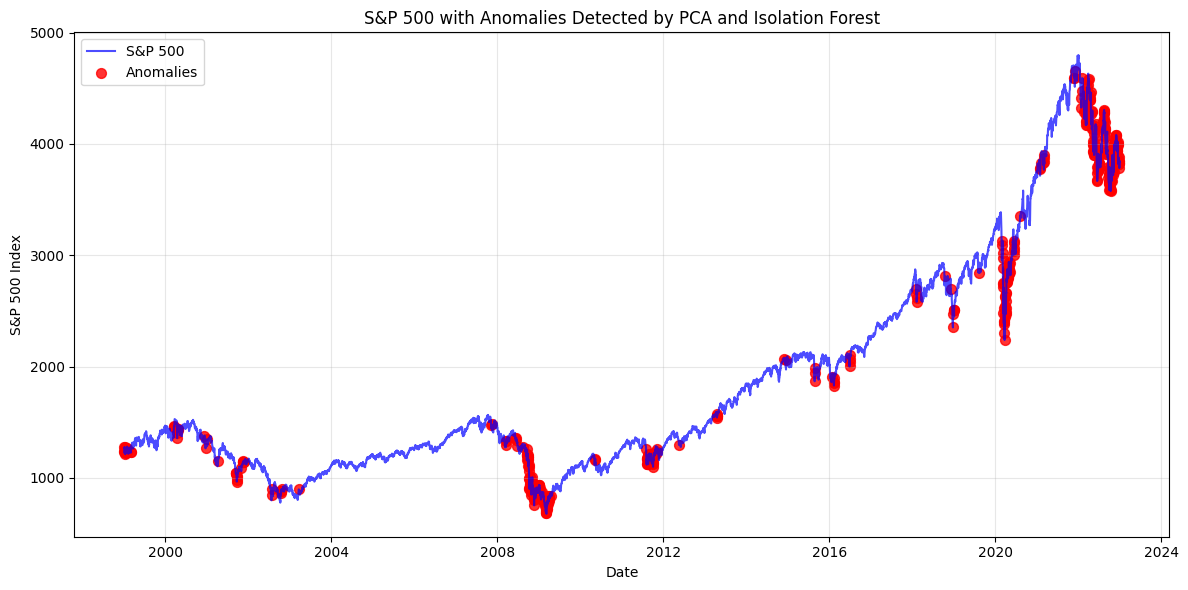

In [73]:
##Run PCA as preliminary step, then Isolation Forest to detect Anomalies
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler


train_data['Date'] = pd.to_datetime(train_data['Date'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(train_data[features])

# Perform PCA
pca = PCA(n_components=18)
X_pca = pca.fit_transform(X_scaled)

#Fit Isolation Forest
isolation_forest = IsolationForest(
    n_estimators=100,
    contamination=0.075,  # Approximate percentage of anomalies
    random_state=42
)
isolation_forest.fit(X_pca)

#  Predict Anomalies
train_data['Isolation_Prediction'] = isolation_forest.predict(X_pca)

# Convert predictions to binary anomalies (1 = anomaly, 0 = normal)
train_data['Isolation_Anomaly'] = (train_data['Isolation_Prediction'] == -1).astype(int)

# Count anomalies
anomalies_count = train_data['Isolation_Anomaly'].sum()
print(f"Total anomalies detected: {anomalies_count}")

#Visualize Anomalies in SP500 Time Series
plt.figure(figsize=(12, 6))
plt.plot(train_data['Date'], train_data['SP500'], label='S&P 500', color='blue', alpha=0.7)
plt.scatter(
    train_data.loc[train_data['Isolation_Anomaly'] == 1, 'Date'],  # Dates of anomalies
    train_data.loc[train_data['Isolation_Anomaly'] == 1, 'SP500'],  # SP500 values of anomalies
    color='red', label='Anomalies', alpha=0.8, marker='o', s=50
)
plt.title('S&P 500 with Anomalies Detected by PCA and Isolation Forest')
plt.xlabel('Date')
plt.ylabel('S&P 500 Index')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


<ipython-input-74-4252765c2a33>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['DBSCAN_Cluster'] = dbscan.fit_predict(X_train_scaled)
<ipython-input-74-4252765c2a33>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['DBSCAN_Anomaly'] = (train_data['DBSCAN_Cluster'] == -1).astype(int)


Silhouette Score (excluding noise): 0.1555800993469428


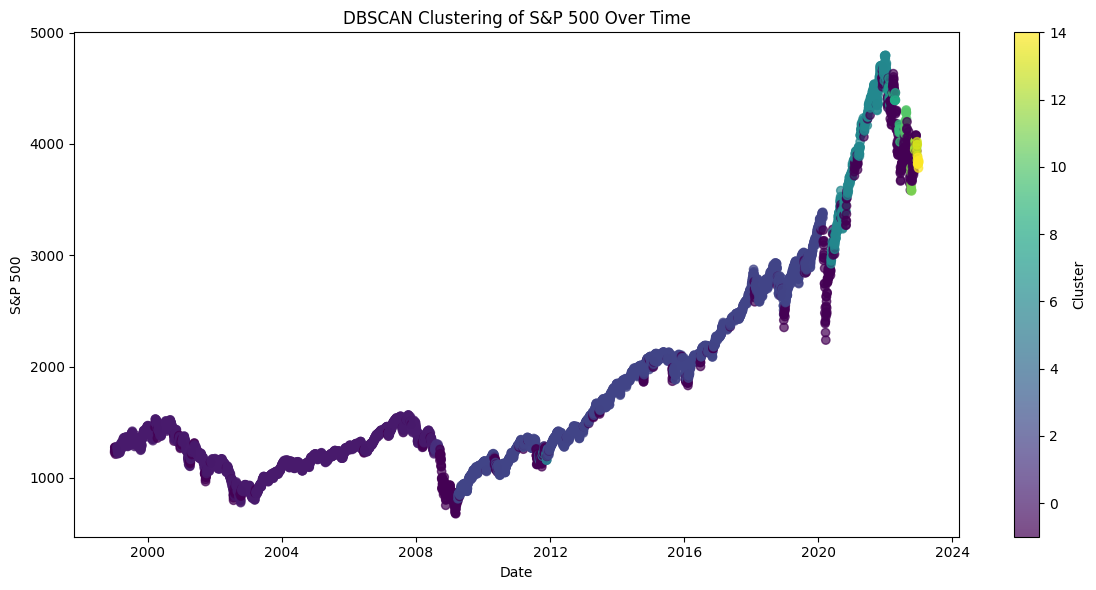

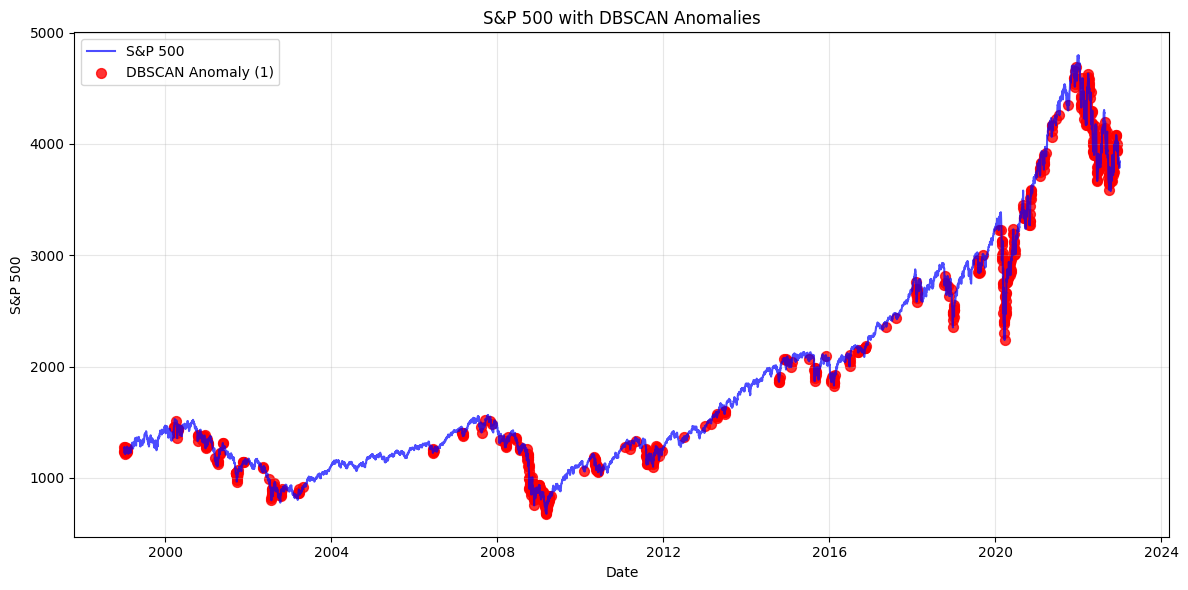

Overlap between DBSCAN and Isolation Forest anomalies: 405


In [74]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_data[features])

#DBSCAN Clustering to determine another perspective on anomalies
dbscan = DBSCAN(eps=4, min_samples=7)
train_data['DBSCAN_Cluster'] = dbscan.fit_predict(X_train_scaled)

# Mark anomalies (cluster == -1)
train_data['DBSCAN_Anomaly'] = (train_data['DBSCAN_Cluster'] == -1).astype(int)

# Evaluate Clustering Quality
try:
    silhouette_avg = silhouette_score(
        X_train_scaled[dbscan.labels_ != -1],
        dbscan.labels_[dbscan.labels_ != -1]
    )
    print(f"Silhouette Score (excluding noise): {silhouette_avg}")
except ValueError as e:
    print(f"Silhouette Score could not be calculated: {e}")

# Visualize Clusters
plt.figure(figsize=(12, 6))
scatter = plt.scatter(
    train_data['Date'],
    train_data['SP500'],
    c=train_data['DBSCAN_Cluster'],
    cmap='viridis',
    alpha=0.7
)

plt.title('DBSCAN Clustering of S&P 500 Over Time')
plt.xlabel('Date')
plt.ylabel('S&P 500')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

#Visualize Anomalies
plt.figure(figsize=(12, 6))
plt.plot(train_data['Date'], train_data['SP500'], label='S&P 500', color='blue', alpha=0.7)

# Highlight DBSCAN Anomalies
plt.scatter(
    train_data.loc[train_data['DBSCAN_Anomaly'] == 1, 'Date'],
    train_data.loc[train_data['DBSCAN_Anomaly'] == 1, 'SP500'],
    color='red', label='DBSCAN Anomaly (1)', alpha=0.8, marker='o', s=50
)

plt.title('S&P 500 with DBSCAN Anomalies')
plt.xlabel('Date')
plt.ylabel('S&P 500')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Compare with Isolation Forest
if 'Isolation_Anomaly' in train_data.columns:
    overlap = train_data['DBSCAN_Anomaly'] & train_data['Isolation_Anomaly']
    print(f"Overlap between DBSCAN and Isolation Forest anomalies: {overlap.sum()}")
else:
    print("Isolation Forest anomalies not available for comparison.")


In [75]:
train_data['Combined_Anomaly'] = train_data['Isolation_Anomaly'] | train_data['DBSCAN_Anomaly']
count = (train_data['Combined_Anomaly'] == 1).sum()
print(count)

828


<ipython-input-75-620846b736b7>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['Combined_Anomaly'] = train_data['Isolation_Anomaly'] | train_data['DBSCAN_Anomaly']


In [76]:
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Combine DBSCAN and Isolation Forest anomalies into a single label
train_data['Combined_Anomaly'] = train_data['Isolation_Anomaly'] | train_data['DBSCAN_Anomaly']


# Select features and target
X = train_data[features]
y = train_data['Combined_Anomaly']




# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Check class distribution after SMOTE
print("Class distribution after SMOTE:")
print(pd.Series(y_train_resampled).value_counts())


Class distribution after SMOTE:
Combined_Anomaly
0    4344
1    4344
Name: count, dtype: int64


<ipython-input-76-1ff27555b9ec>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['Combined_Anomaly'] = train_data['Isolation_Anomaly'] | train_data['DBSCAN_Anomaly']


In [77]:
# Train the XGBoost model  to detect Anomalies
anomaly_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)
anomaly_model.fit(X_train_resampled, y_train_resampled)

# Predict on test data
y_pred = anomaly_model.predict(X_test)
y_pred_prob = anomaly_model.predict_proba(X_test)[:, 1]

# Evaluate the model
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"\nROC-AUC Score: {roc_auc:.4f}")



Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1086
           1       0.80      0.92      0.86       166

    accuracy                           0.96      1252
   macro avg       0.89      0.94      0.92      1252
weighted avg       0.96      0.96      0.96      1252


Confusion Matrix:
[[1048   38]
 [  13  153]]

ROC-AUC Score: 0.9856


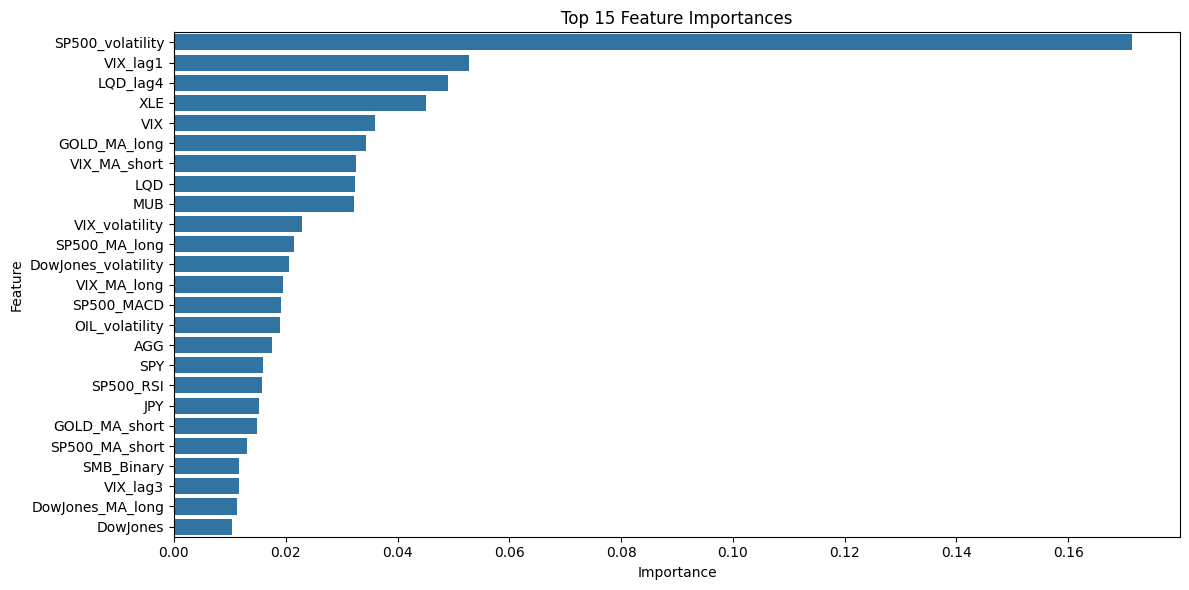

In [78]:
# Feature importance
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': anomaly_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances.head(25))
plt.title('Top 15 Feature Importances')
plt.tight_layout()
plt.show()


<ipython-input-79-4efd628d05e7>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['Crash_Warning'] = ((train_data['Crash_3D'] == 1) |
<ipython-input-79-4efd628d05e7>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['Crisis_Warning'] = ((train_data['Crisis_3D'] == 1) |
<ipython-input-79-4efd628d05e7>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation

Class distribution after SMOTE:
Warning
0    4128
1    4128
Name: count, dtype: int64

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.88      0.90      1033
           1       0.55      0.68      0.61       219

    accuracy                           0.85      1252
   macro avg       0.74      0.78      0.76      1252
weighted avg       0.86      0.85      0.85      1252



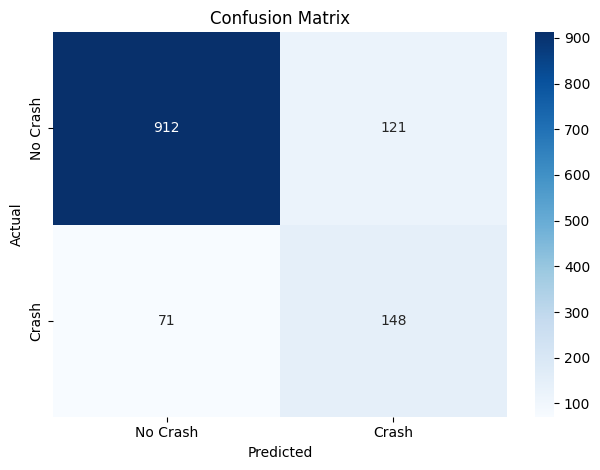


ROC-AUC Score: 0.8838


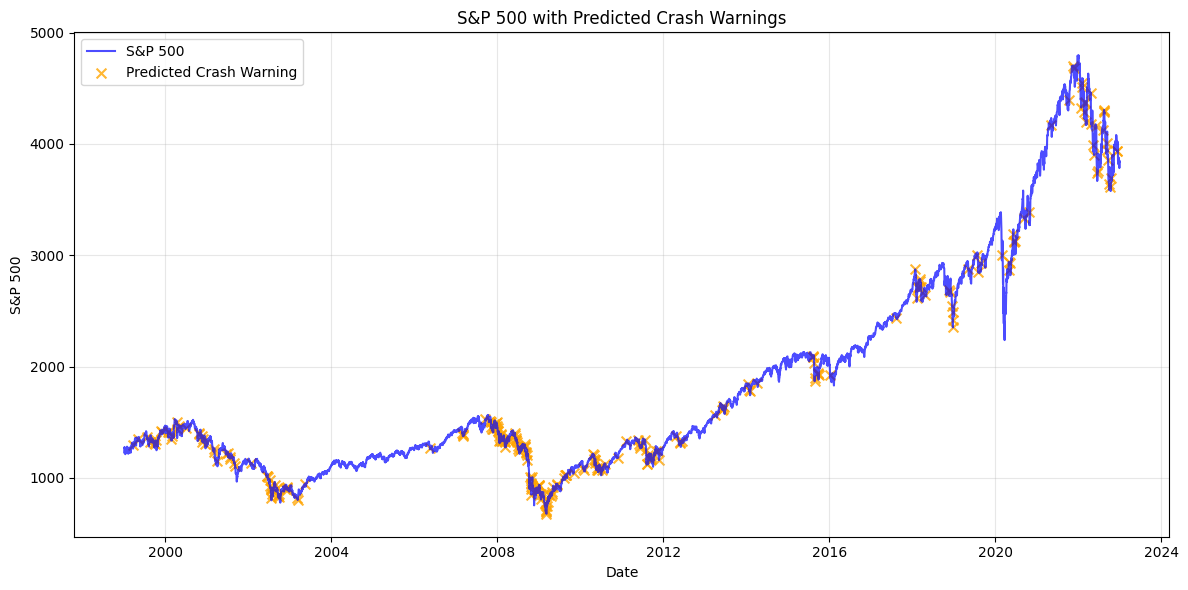

In [79]:
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# Step 3.5: Binary Classification with Crash Warning
train_data['Crash_Warning'] = ((train_data['Crash_3D'] == 1) |
                               (train_data['Crash_5D'] == 1) |
                                (train_data['Crash_7D'] == 1) |
                               (train_data['Crash_1D'] == 1)).astype(int)

# Step 3.5: Binary Classification with Crash Warning
train_data['Crisis_Warning'] = ((train_data['Crisis_3D'] == 1) |
                               (train_data['Crisis_5D'] == 1) |
                                (train_data['Crisis_7D'] == 1) |
                               (train_data['Crisis_1D'] == 1)).astype(int)


train_data['Warning'] = ((train_data['Crash_Warning'] == 1) | (train_data['Crisis_Warning'] == 1)).astype(int)

X_classification = train_data[features]
y_classification = train_data['Warning']

X_train, X_test, y_train, y_test = train_test_split(X_classification, y_classification,
                                                    test_size=0.2, random_state=42, stratify=y_classification)

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Check class distribution after SMOTE
print("Class distribution after SMOTE:")
print(pd.Series(y_train_resampled).value_counts())


# Train the XGBoost classifier
crash_classifier = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
crash_classifier.fit(X_train_resampled, y_train_resampled)


# Predict on the test set
y_pred = crash_classifier.predict(X_test)
y_pred_prob = crash_classifier.predict_proba(X_test)[:, 1]

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Crash', 'Crash'], yticklabels=['No Crash', 'Crash'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# ROC-AUC score
roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"\nROC-AUC Score: {roc_auc:.4f}")

# Create a copy of test data to include predictions
test_data = train_data.loc[X_test.index].copy()  # Align with X_test indices
test_data['Crash_Prediction'] = y_pred  # Add predictions to the test dataset

# Plot S&P 500 with predicted crash warnings
plt.figure(figsize=(12, 6))
plt.plot(train_data['Date'], train_data['SP500'], label='S&P 500', color='blue', alpha=0.7)

# Highlight predicted crash warnings
plt.scatter(
    test_data.loc[test_data['Crash_Prediction'] == 1, 'Date'],  # Filter for predicted crashes
    test_data.loc[test_data['Crash_Prediction'] == 1, 'SP500'],  # SP500 values for predicted crashes
    color='orange', label='Predicted Crash Warning', alpha=0.8, marker='x', s=50
)

plt.title('S&P 500 with Predicted Crash Warnings')
plt.xlabel('Date')
plt.ylabel('S&P 500')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [81]:
X_verify = verify_data[features]

In [82]:
# Anomaly prediction using xgb_model
verify_data['Anomaly_Prediction'] = anomaly_model.predict(X_verify)
verify_data['Anomaly_Probability'] = anomaly_model.predict_proba(X_verify)[:, 1]

# Crash prediction using crash_classifier
verify_data['Crash_Prediction'] = crash_classifier.predict(X_verify)
verify_data['Crash_Probability'] = crash_classifier.predict_proba(X_verify)[:, 1]

<ipython-input-82-d91ceaa30458>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  verify_data['Anomaly_Prediction'] = anomaly_model.predict(X_verify)
<ipython-input-82-d91ceaa30458>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  verify_data['Anomaly_Probability'] = anomaly_model.predict_proba(X_verify)[:, 1]
<ipython-input-82-d91ceaa30458>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats i

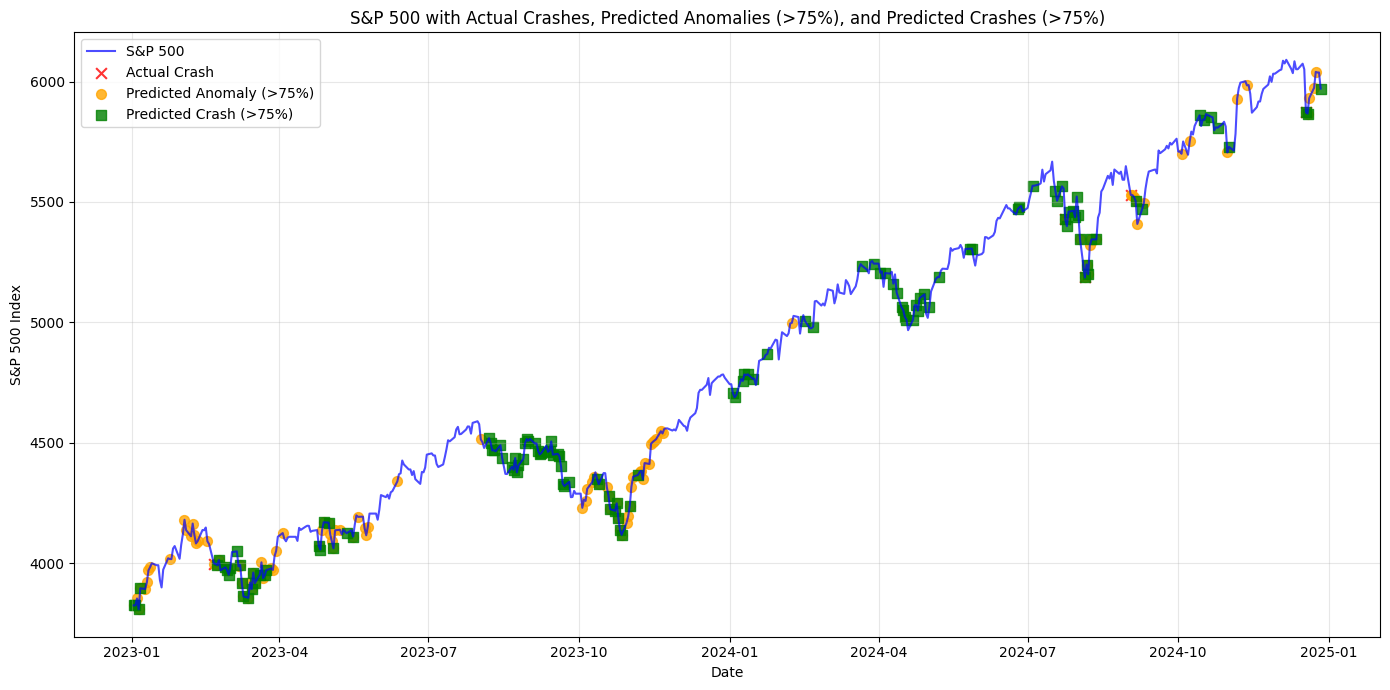

In [83]:
# Plot S&P 500 with predictions and actual crashes
plt.figure(figsize=(14, 7))

# Plot SP500 time series
plt.plot(verify_data['Date'], verify_data['SP500'], label='S&P 500', color='blue', alpha=0.7)

# Highlight actual crashes
plt.scatter(
    verify_data.loc[verify_data['Crash'] == 1, 'Date'],
    verify_data.loc[verify_data['Crash'] == 1, 'SP500'],
    color='red', label='Actual Crash', alpha=0.8, marker='x', s=60
)

# plt.scatter(
#     verify_data.loc[verify_data['crisis'] == 1, 'Date'],
#     verify_data.loc[verify_data['crisis'] == 1, 'SP500'],
#     color='purple', label='Actual Crisis', alpha=0.8, marker='x', s=60
# )

# Highlight predicted anomalies with > 75% probability
plt.scatter(
    verify_data.loc[verify_data['Anomaly_Probability'] > 0.75, 'Date'],
    verify_data.loc[verify_data['Anomaly_Probability'] > 0.75, 'SP500'],
    # verify_data.loc[verify_data['Anomaly_Prediction'] == 1, 'Date'],
    # verify_data.loc[verify_data['Anomaly_Prediction'] == 1, 'SP500'],
    color='orange', label='Predicted Anomaly (>75%)', alpha=0.8, marker='o', s=50
)

# Highlight predicted crashes with > 75% probability
plt.scatter(
    # verify_data.loc[verify_data['Crash_Probability'] > 0.35, 'Date'],
    # verify_data.loc[verify_data['Crash_Probability'] > 0.35, 'SP500'],
    verify_data.loc[verify_data['Crash_Prediction'] == 1, 'Date'],
    verify_data.loc[verify_data['Crash_Prediction'] == 1, 'SP500'],
    color='green', label='Predicted Crash (>75%)', alpha=0.8, marker='s', s=50
)

# plt.scatter(
#     verify_data.loc[verify_data['Crisis_Probability'] > 0.2, 'Date'],
#     verify_data.loc[verify_data['Crisis_Probability'] > 0.2, 'SP500'],
#     color='pink', label='Predicted Crisis (>5%)', alpha=0.8, marker='s', s=50
# )

# Add plot details
plt.title('S&P 500 with Actual Crashes, Predicted Anomalies (>75%), and Predicted Crashes (>75%)')
plt.xlabel('Date')
plt.ylabel('S&P 500 Index')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


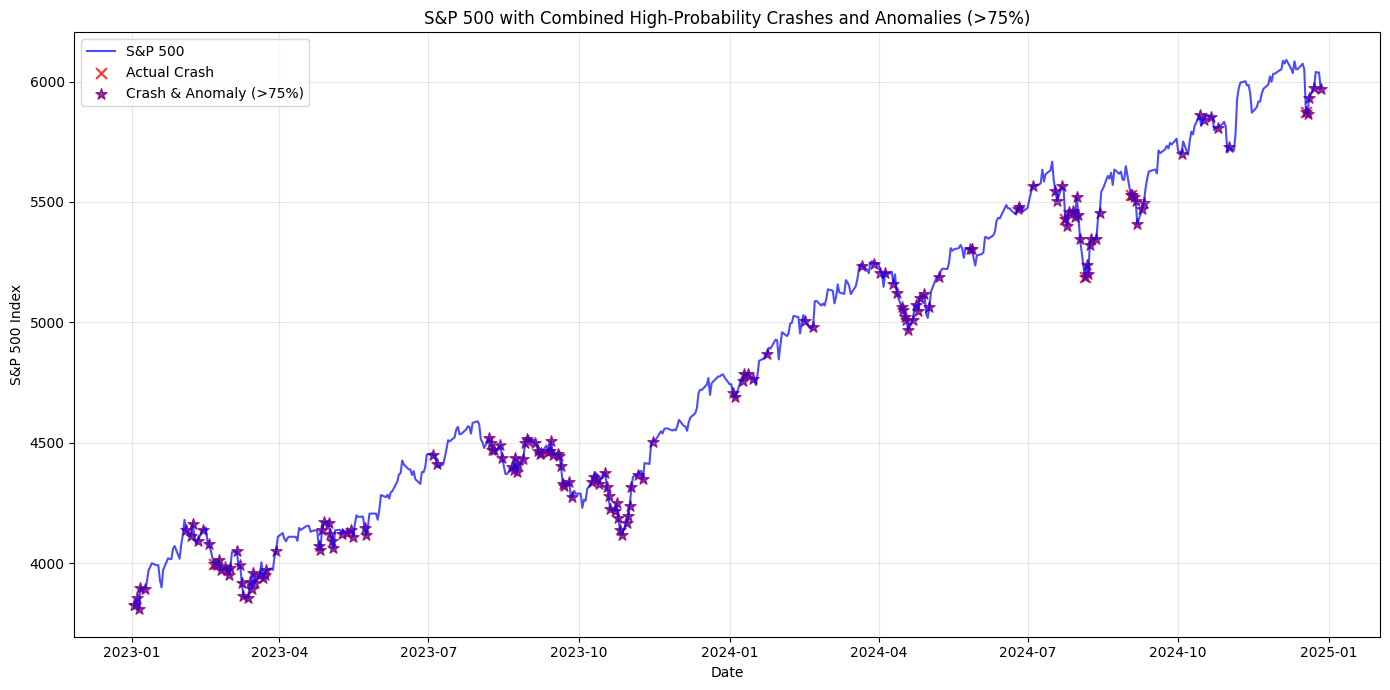

In [84]:
# Create a condition where both crash and anomaly probabilities are over 75%
both_high_prob =  ( (verify_data['Crash_Probability'] > .3)  & (verify_data['Anomaly_Probability'] > 0.65) ) | verify_data['Crash_Prediction'] == 1
# Plot S&P 500 with only combined high-probability crash and anomaly
plt.figure(figsize=(14, 7))

# Plot SP500 time series
plt.plot(verify_data['Date'], verify_data['SP500'], label='S&P 500', color='blue', alpha=0.7)

# Highlight actual crashes
plt.scatter(
    verify_data.loc[verify_data['Crash'] == 1, 'Date'],
    verify_data.loc[verify_data['Crash'] == 1, 'SP500'],
    color='red', label='Actual Crash', alpha=0.8, marker='x', s=60
)

# Highlight instances with both crash and anomaly > 75% probability
plt.scatter(
    verify_data.loc[both_high_prob, 'Date'],
    verify_data.loc[both_high_prob, 'SP500'],
    color='purple', label='Crash & Anomaly (>75%)', alpha=0.8, marker='*', s=70
)

# Add plot details
plt.title('S&P 500 with Combined High-Probability Crashes and Anomalies (>75%)')
plt.xlabel('Date')
plt.ylabel('S&P 500 Index')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [85]:
from sklearn.preprocessing import StandardScaler



# Filter train_data to include only the specified features
X = data[features]

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Total anomalies detected: 509


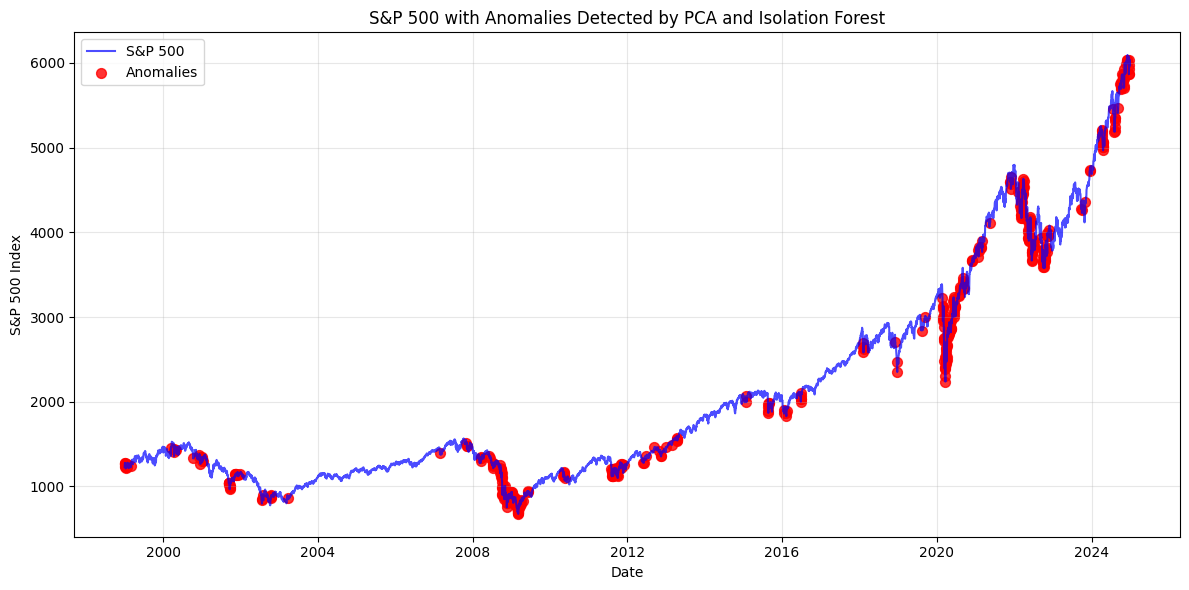

In [96]:
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

data['Date'] = pd.to_datetime(data['Date'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data[features])

# Perform PCA
pca = PCA(n_components=18)
X_pca = pca.fit_transform(X_scaled)

#  Fit Isolation Forest
isolation_forest = IsolationForest(
    n_estimators=100,
    contamination=0.075,
    random_state=42
)
isolation_forest.fit(X_pca)

# Predict (-1 = anomaly, 1 = normal)
data['Isolation_Prediction'] = isolation_forest.predict(X_pca)

# Convert predictions to binary anomalies (1 = anomaly, 0 = normal)
data['Isolation_Anomaly'] = (data['Isolation_Prediction'] == -1).astype(int)

# Count anomalies
anomalies_count = data['Isolation_Anomaly'].sum()
print(f"Total anomalies detected: {anomalies_count}")

# Visualize Anomalies in SP500 Time Series
plt.figure(figsize=(12, 6))
plt.plot(data['Date'], data['SP500'], label='S&P 500', color='blue', alpha=0.7)
plt.scatter(
    data.loc[data['Isolation_Anomaly'] == 1, 'Date'],
    data.loc[data['Isolation_Anomaly'] == 1, 'SP500'],
    color='red', label='Anomalies', alpha=0.8, marker='o', s=50
)

plt.title('S&P 500 with Anomalies Detected by PCA and Isolation Forest')
plt.xlabel('Date')
plt.ylabel('S&P 500 Index')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Silhouette Score (excluding noise): 0.05124779753185503


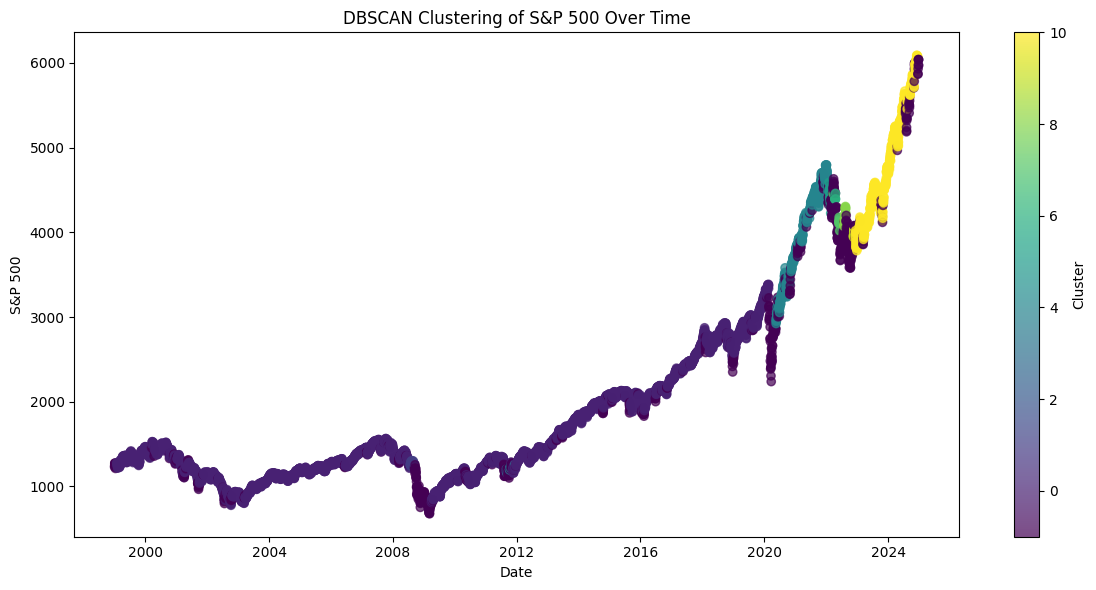

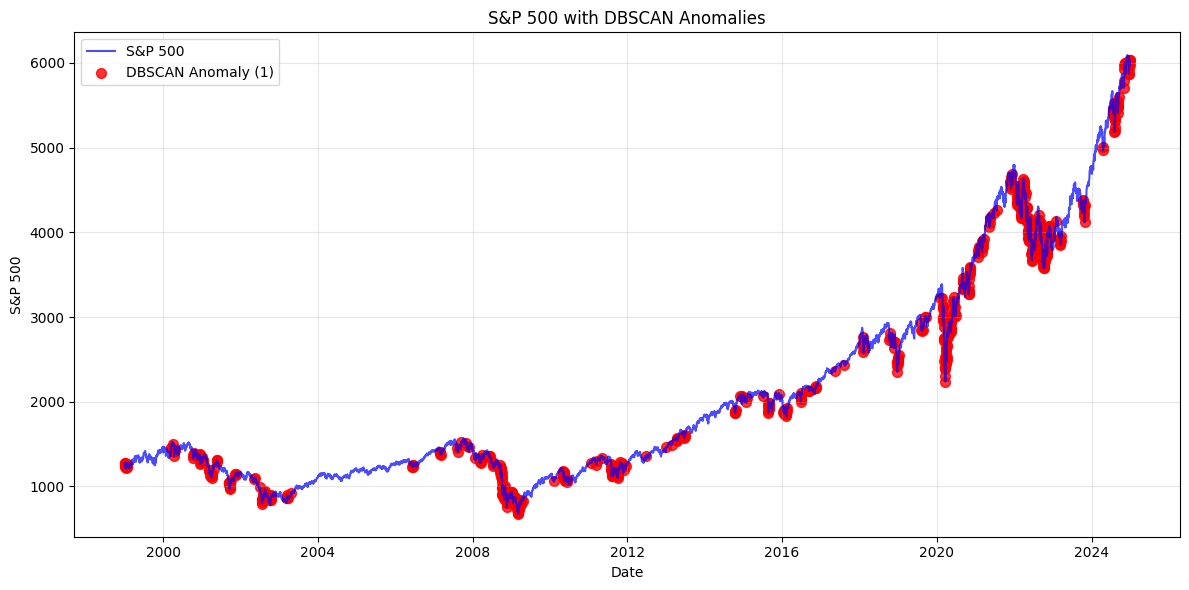

Overlap between DBSCAN and Isolation Forest anomalies: 431


In [97]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(data[features])

#  DBSCAN Clustering
dbscan = DBSCAN(eps=4, min_samples=7)
data['DBSCAN_Cluster'] = dbscan.fit_predict(X_train_scaled)

data['DBSCAN_Anomaly'] = (data['DBSCAN_Cluster'] == -1).astype(int)

try:
    silhouette_avg = silhouette_score(
        X_train_scaled[dbscan.labels_ != -1],
        dbscan.labels_[dbscan.labels_ != -1]
    )
    print(f"Silhouette Score (excluding noise): {silhouette_avg}")
except ValueError as e:
    print(f"Silhouette Score could not be calculated: {e}")

#  Visualize
plt.figure(figsize=(12, 6))
scatter = plt.scatter(
    data['Date'],
    data['SP500'],
    c=data['DBSCAN_Cluster'],
    cmap='viridis',
    alpha=0.7
)

plt.title('DBSCAN Clustering of S&P 500 Over Time')
plt.xlabel('Date')
plt.ylabel('S&P 500')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 6))
plt.plot(data['Date'], data['SP500'], label='S&P 500', color='blue', alpha=0.7)

plt.scatter(
    data.loc[data['DBSCAN_Anomaly'] == 1, 'Date'],
    data.loc[data['DBSCAN_Anomaly'] == 1, 'SP500'],
    color='red', label='DBSCAN Anomaly (1)', alpha=0.8, marker='o', s=50
)

plt.title('S&P 500 with DBSCAN Anomalies')
plt.xlabel('Date')
plt.ylabel('S&P 500')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

if 'Isolation_Anomaly' in data.columns:
    overlap = data['DBSCAN_Anomaly'] & data['Isolation_Anomaly']
    print(f"Overlap between DBSCAN and Isolation Forest anomalies: {overlap.sum()}")
else:
    print("Isolation Forest anomalies not available for comparison.")


In [98]:
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Combine DBSCAN and Isolation Forest anomalies into a single label
data['Combined_Anomaly'] = data['Isolation_Anomaly'] | data['DBSCAN_Anomaly']

# Select features and target
X = data[features]
y = data['Combined_Anomaly']




# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Check class distribution after SMOTE
print("Class distribution after SMOTE:")
print(pd.Series(y_train_resampled).value_counts())


Class distribution after SMOTE:
Combined_Anomaly
0    3526
1    3526
Name: count, dtype: int64


In [99]:
# Train the XGBoost model
anomaly_classifier = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)
anomaly_classifier.fit(X_train_resampled, y_train_resampled)

y_pred = anomaly_classifier.predict(X_test)
y_pred_prob = anomaly_classifier.predict_proba(X_test)[:, 1]

# Evaluate the model
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"\nROC-AUC Score: {roc_auc:.4f}")


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      2351
           1       0.76      0.87      0.81       361

    accuracy                           0.95      2712
   macro avg       0.87      0.91      0.89      2712
weighted avg       0.95      0.95      0.95      2712


Confusion Matrix:
[[2251  100]
 [  48  313]]

ROC-AUC Score: 0.9766


Class distribution after SMOTE:
Warning
1    4696
0    4696
Name: count, dtype: int64


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [00:27:16] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.81      0.87      1174
           1       0.35      0.66      0.45       182

    accuracy                           0.79      1356
   macro avg       0.64      0.73      0.66      1356
weighted avg       0.86      0.79      0.81      1356



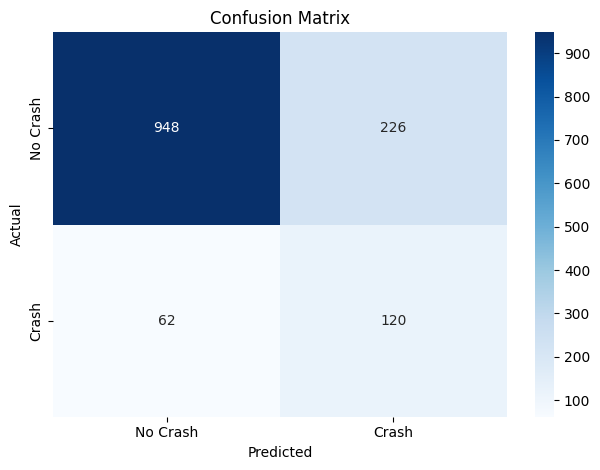


ROC-AUC Score: 0.8239


In [100]:
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# Binary Classification with Crash Warning
data['Crash_Warning'] = ((data['Crash_3D'] == 1) |
                               (data['Crash_5D'] == 1) |
                               (data['Crash_1D'] == 1)).astype(int)

# Binary Classification with crisis Warning
data['Crisis_Warning'] = ((data['Crisis_3D'] == 1) |
                               (data['Crisis_5D'] == 1) |
                               (data['Crisis_1D'] == 1)).astype(int)


data['Warning'] = ((data['Crash_Warning'] == 1) | (data['Crisis_Warning'] == 1)).astype(int)

X_classification = data[features]
y_classification = data['Warning']

X_train, X_test, y_train, y_test = train_test_split(X_classification, y_classification,
                                                    test_size=0.2, random_state=42, stratify=y_classification)

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Check class distribution after SMOTE
print("Class distribution after SMOTE:")
print(pd.Series(y_train_resampled).value_counts())


# Train the XGBoost classifier
crash_classifier = XGBClassifier(
    n_estimators=200,
    learning_rate=0.025,
    max_depth=4,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
crash_classifier.fit(X_train_resampled, y_train_resampled)


# Predict on the test set
y_pred = crash_classifier.predict(X_test)
y_pred_prob = crash_classifier.predict_proba(X_test)[:, 1]

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Crash', 'Crash'], yticklabels=['No Crash', 'Crash'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# ROC-AUC score
roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"\nROC-AUC Score: {roc_auc:.4f}")

# Create a copy of test data to include predictions
test_data = data.loc[X_test.index].copy()  # Align with X_test indices
test_data['Crash_Prediction'] = y_pred  # Add predictions to the test dataset




In [101]:
# Anomaly prediction using xgb_model
data['Anomaly_Prediction'] = anomaly_classifier.predict(data[features])
data['Anomaly_Probability'] = anomaly_classifier.predict_proba(data[features])[:, 1]

# Crash prediction using crash_classifier
data['Crash_Prediction'] = crash_classifier.predict(data[features])
data['Crash_Probability'] = crash_classifier.predict_proba(data[features])[:, 1]

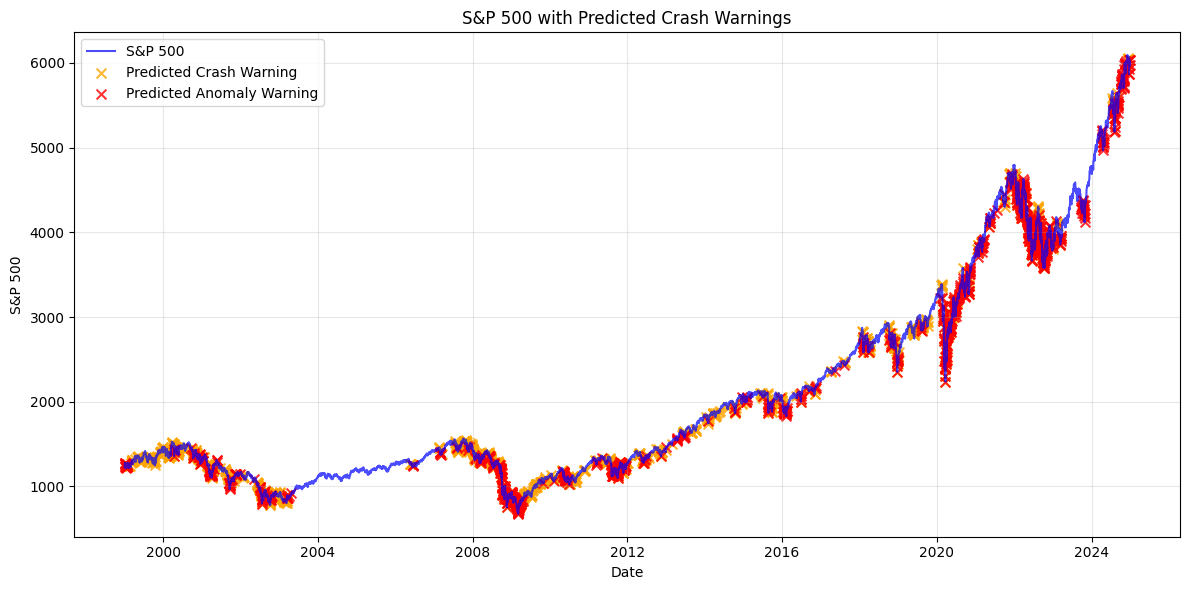

In [103]:
plt.figure(figsize=(12, 6))
plt.plot(data['Date'], data['SP500'], label='S&P 500', color='blue', alpha=0.7)

plt.scatter(
    data.loc[data['Crash_Prediction'] == 1, 'Date'],
    data.loc[data['Crash_Prediction'] == 1, 'SP500'],
    color='orange', label='Predicted Crash Warning', alpha=0.8, marker='x', s=50
)
plt.scatter(
    data.loc[data['Anomaly_Prediction'] == 1, 'Date'],
    data.loc[data['Anomaly_Prediction'] == 1, 'SP500'],
    color='red', label='Predicted Anomaly Warning', alpha=0.8, marker='x', s=50
)



plt.title('S&P 500 with Predicted Crash Warnings')
plt.xlabel('Date')
plt.ylabel('S&P 500')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<ipython-input-104-1d641bc9b59c>:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['Combined'] = data['Anomaly_Prediction'] & data['Crash_Prediction']


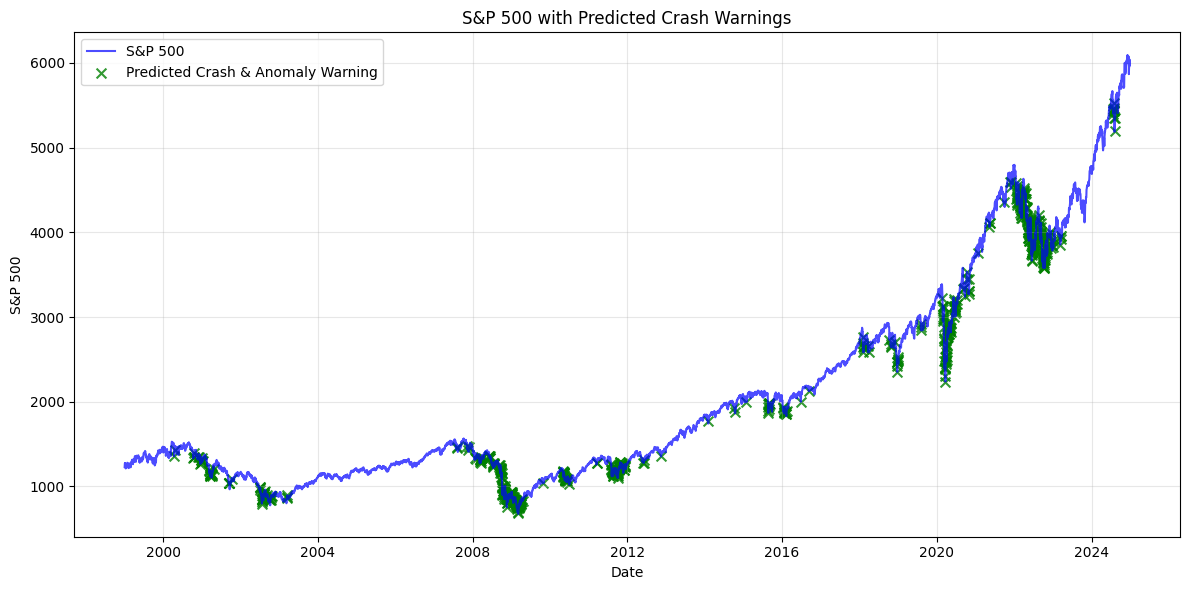

In [104]:
data['Combined'] = data['Anomaly_Prediction'] & data['Crash_Prediction']

plt.figure(figsize=(12, 6))
plt.plot(data['Date'], data['SP500'], label='S&P 500', color='blue', alpha=0.7)

plt.scatter(
    data.loc[data['Combined'] == 1, 'Date'],
    data.loc[data['Combined'] == 1, 'SP500'],
    color='green', label='Predicted Crash & Anomaly Warning', alpha=0.8, marker='x', s=50
)



plt.title('S&P 500 with Predicted Crash Warnings')
plt.xlabel('Date')
plt.ylabel('S&P 500')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [105]:
import pickle

# Save the model to a file
with open('anomaly_classifier.pkl', 'wb') as file:
    pickle.dump(anomaly_classifier, file)

with open('crash_classifier.pkl', 'wb') as file:
    pickle.dump(crash_classifier, file)

In [80]:
import pickle

with open('anomaly_classifier.pkl', 'rb') as file:
    anomaly_classifier = pickle.load(file)
with open('crash_classifier.pkl', 'rb') as file:
    crash_classifier = pickle.load(file)

FileNotFoundError: [Errno 2] No such file or directory: 'anomaly_classifier.pkl'

In [106]:
data.to_csv('historical_data.csv')